# Performance benchmarking

Per layer, one 2048-token sequence (ridge 17.2 op/byte)
  FA          34.4 Gop      40.0 MiB    819.6 op/byte    882 op/cycle     39.0 ms
  MLP        721.6 Gop    1896.0 MiB    362.9 op/byte   1092 op/cycle    660.9 ms
  FA+MLP     755.9 Gop    1936.0 MiB    372.4 op/byte   1080 op/cycle    699.9 ms
TTFT:  22.4 s


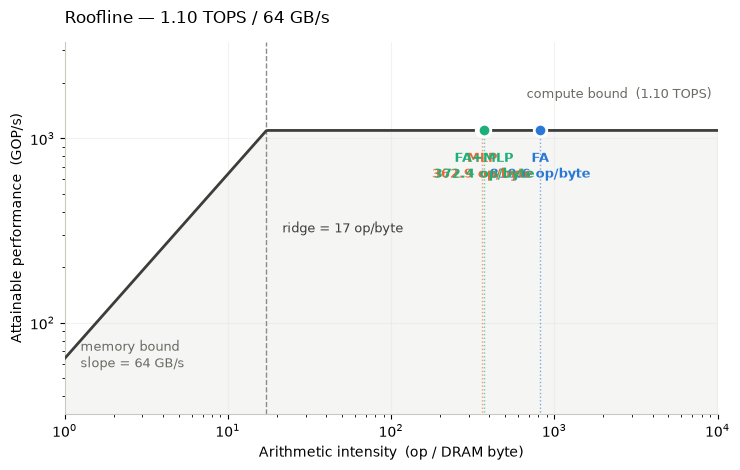

In [1]:
from tile_model import Hardware, data_bytes, divup
from fa import flash_attention
from mlp import mlp
from helper import T, S, H, G, K, D, F, L, plot_roofline

hw = Hardware()
Mt = 192 # MLP tile
fa = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, Br_sa1=None, R=256, hw=hw, verbose=False)
ml = mlp(M=T, D=D, F=F, Mt=Mt, Ft=256, Mt_sa1=None, R=256, hw=hw, verbose=False)

# FlashAttention, K groups per layer
fa_ops   = K * 2 * 2 * G * H * T * (T + 1) // 2           # QK^T + PV
fa_bytes = K * (data_bytes((2*S, H), 16) + data_bytes((2*G*T, H), 16))
fa_cyc   = K * fa['cycles']

# MLP:
mlp_ops   = 2 * T * 3 * D * F                              # gate, up, down
mlp_bytes = data_bytes((3*T, D), 16) + divup(T, Mt) * data_bytes((3*D, F), 8)
mlp_cyc   = ml['cycles']

ridge_ops, ridge_mem = 2 * 552, hw.dma_bw                    # op/cycle, byte/cycle
rows = [("FA", fa_ops, fa_bytes, fa_cyc), ("MLP", mlp_ops, mlp_bytes, mlp_cyc),
        ("FA+MLP", fa_ops + mlp_ops, fa_bytes + mlp_bytes, fa_cyc + mlp_cyc)]

print(f"Per layer, one {T}-token sequence (ridge {ridge_ops/ridge_mem:.1f} op/byte)")
for name, ops, nbytes, cyc in rows:
    print(f"  {name:7s} {ops/1e9:8.1f} Gop  {nbytes/2**20:8.1f} MiB  "
          f"{ops/nbytes:7.1f} op/byte  {ops/cyc:5.0f} op/cycle  {hw.time_us(cyc)/1e3:7.1f} ms")

plot_roofline([(name, round(ops/nbytes, 1)) for name, ops, nbytes, _ in rows], ridge_ops, ridge_mem)

print("TTFT: ", round(L * hw.time_us(cyc)/1e3/1e3, 1), "s")

In [9]:
print(fa["utilization"])
print(ml["utilization"])


{'DMA': 0.023745623875637938, 'VCPU': 0.5843241536209717, 'SA1+SA2': 0.9943613377248647}
{'DMA': 0.047767138692194504, 'VCPU': 0.1672367932151232, 'SA1+SA2': 0.9997724950974342}


Per layer, one decode step of B=16 sequences at S=2048 context (ridge 17.2 op/byte)
  FA        0.537 Gop    64.2 MiB    8.0 op/byte    118 op/cycle   4.564 ms     23% of the memory roof
  MLP       5.637 Gop   168.4 MiB   31.9 op/byte   1029 op/cycle   5.479 ms     93% of the compute roof
  FA+MLP    6.174 Gop   232.6 MiB   25.3 op/byte    615 op/cycle  10.043 ms     56% of the compute roof
TPOT: 321.4 ms/step = 20.09 ms/token, 50 tok/s aggregate
  floors per step: weights 88.1 ms, KV cache 33.6 ms


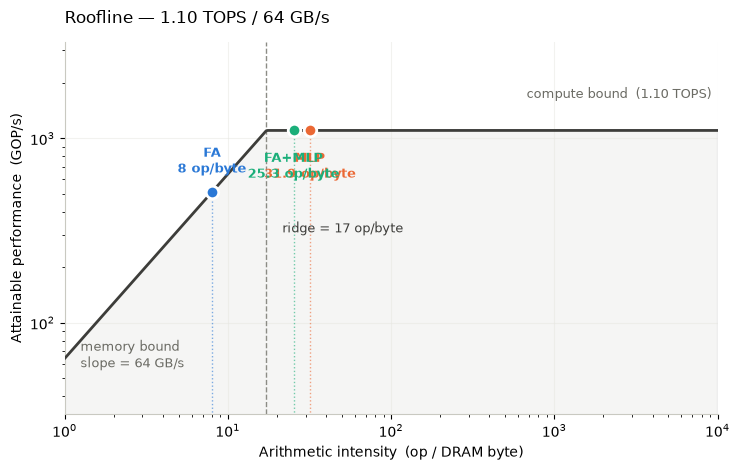

In [3]:
from fa import flash_decode
from mlp import mlp_decode
from helper import B

# One decode step: every sequence emits one token. Attention runs per sequence
# (each owns its KV cache) -> B*K groups per layer; the MLP runs ONCE for the
# whole batch, because all B token rows share the same weights.
fad = flash_decode(S=S, H=H, G=G, Bc=1024, R=256, hw=hw, verbose=False)
mld = mlp_decode(M=B, D=D, F=F, Ft=256, R=256, hw=hw, verbose=False)

fad_ops   = B * K * 2 * 2 * G * H * S                    # QK^T + PV over every cached key
fad_bytes = B * K * (data_bytes((2*S, H), 8)             # INT8 K + pre-transposed V
                     + data_bytes((2*G, H), 16))         # Q16 in, O16 out
fad_cyc   = B * K * fad['cycles']

mld_ops   = 2 * B * 3 * D * F                            # gate, up, down
mld_bytes = data_bytes((3*B, D), 16) + data_bytes((3*D, F), 8)   # weights once per step
mld_cyc   = mld['cycles']

rows = [("FA", fad_ops, fad_bytes, fad_cyc), ("MLP", mld_ops, mld_bytes, mld_cyc),
        ("FA+MLP", fad_ops + mld_ops, fad_bytes + mld_bytes, fad_cyc + mld_cyc)]

print(f"Per layer, one decode step of B={B} sequences at S={S} context "
      f"(ridge {ridge_ops/ridge_mem:.1f} op/byte)")
for name, ops, nbytes, cyc in rows:
    roof = min(ridge_ops, ops/nbytes * ridge_mem)        # the roofline at this intensity
    print(f"  {name:7s} {ops/1e9:7.3f} Gop {nbytes/2**20:7.1f} MiB {ops/nbytes:6.1f} op/byte"
          f" {ops/cyc:6.0f} op/cycle {hw.time_us(cyc)/1e3:7.3f} ms"
          f"   {100*ops/cyc/roof:4.0f}% of the {'compute' if roof == ridge_ops else 'memory'} roof")

plot_roofline([(name, round(ops/nbytes, 1)) for name, ops, nbytes, _ in rows],
              ridge_ops, ridge_mem)

step = L * (fad_cyc + mld_cyc)
print(f"TPOT: {hw.time_us(step)/1e3:.1f} ms/step = {hw.time_us(step)/1e3/B:.2f} ms/token, "
      f"{B/(hw.time_us(step)/1e6):.0f} tok/s aggregate")
print(f"  floors per step: weights {L*3*D*F/hw.dma_bw/1e6:.1f} ms, "
      f"KV cache {L*B*K*2*S*H/hw.dma_bw/1e6:.1f} ms")

In [10]:
print(fad["utilization"])
print(mld["utilization"])

{'DMA': 0.29656429673257606, 'VCPU': 0.3814892721918384, 'SA1+SA2': 0.5373720375823867}
{'DMA': 0.5118769395423999, 'VCPU': 0.20709982710547406, 'SA1+SA2': 0.9912468610052485}


# Parallelization